In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split

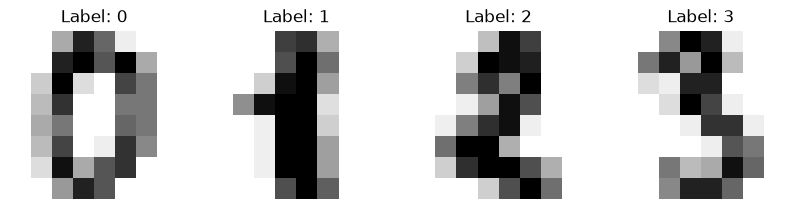

In [2]:
digits = datasets.load_digits()

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("Label: %i" % label)

$$
X \in \mathbb{R}^{64 \times m}, \; m = no. of samples
\\
y \in {\{0, 1\}}^{c \times m}, \; c = classes
$$

In [3]:
n_samples = len(digits.images)
input = digits.images.reshape((n_samples, -1))
target = np.eye(10)[digits.target]

X_train, X_test, y_train, y_test = train_test_split(
    input, target, test_size=0.2, shuffle=True
)

X_train = X_train.T
X_test = X_test.T
y_train = y_train.T
y_test = y_test.T

$$
W_1 \in \mathbb{R}^{16 \times 64}, \; B_1 \in \mathbb{R}^{16 \times 1}
\\
W_2 \in \mathbb{R}^{10 \times 16}, \; B_2 \in \mathbb{R}^{10 \times 1}
$$

In [4]:
W1 = np.random.rand(16, 64) - 0.5
B1 = np.random.rand(16, 1) - 0.5

W2 = np.random.rand(10, 16) - 0.5
B2 = np.random.rand(10, 1) - 0.5

# Forward Pass

$$
Z_1 = W_1X + B_1
\\
A_1 = \sigma(Z_1)
$$
$$
Z_2 = W_2A_1 + B_2
\\
\hat{Y} = softmax(Z_2)
$$

In [5]:
def forward(X):
    Z1 = np.dot(W1, X) + B1
    A1 = 1 / (1 + np.exp(-Z1))

    Z2 = np.dot(W2, A1) + B2
    y_hat = np.exp(Z2)
    y_hat /= np.sum(y_hat, axis=0, keepdims=True)

    return A1, y_hat

# Loss

the cross-entorpy loss
$$
L = - \frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{c} y_{k, i} \log\hat{y}_{k, i}
$$

In [6]:
def loss(y, y_hat):
    return -np.mean(np.log(y_hat.T[np.arange(y.shape[1]), np.argmax(y, axis=0)]))

# Backward Pass

## Softmax Cross-Entorpy Gradient

the loss for a single sample is,
$$
l = - \sum_k y_k \log p_k
$$
where $p_k$ is the softmax,
$$
p_k = \frac{e^{z_k}}{\sum_j e^{z_j}}
$$
the jacobian of the softmax is given by,
$$
\frac{\partial p_k}{\partial z_j} = p_k(\delta_{kj} - p_j), \; \delta_{kj} = 1 \, if \, k = j, \, else \, 0
$$
using chain rule, we can deduce that,
$$
\frac{\partial l}{\partial z_j} = \sum_k \frac{\partial l}{\partial p_k} \frac{\partial p_k}{\partial z_j} = \sum_k (-\frac{y_k}{p_k})p_k(\delta_{kj}-p_j)
$$
$$
= -\sum_k y_k (\delta_{kj} - p_j) = -y_j + p_j \sum_k y_k
$$
and since y is one-hot, $\sum_k y_k = 1$, so
$$
\frac{\partial l}{\partial z_j} = p_j - y_j
$$
the batched gradient is,
$$
\boxed{dZ_2 \equiv \frac{\partial L}{\partial Z_2} = \hat{Y} - Y}
$$

## Weights & Bias Gradient

for a single sample,
$$
z_{2, k} = \sum_l W_{2, kl}a_{1, l} + b_{2, k}
$$
then, the gradient is,
$$
\frac{\partial z_{2, k}}{\partial W_{2, kl}} = a_{1, l}
$$
batching the samples and using chain rule,
$$
\frac{\partial L}{\partial W_{2, kl}} = \frac{1}{m}\sum_i \frac{\partial L}{\partial z_{2,k,i}} \cdot \frac{\partial z_{2,k,i}}{\partial W_{2, kl}} = \frac{1}{m}\sum_i (dZ_2)_{k,i} (A_1)_{l,i} = \frac{1}{m}(dZ_2A_1^T)_{kl}
$$
$$
\boxed{dW_2 \equiv \frac{\partial L}{\partial W_2} = \frac{1}{m}dZ_2A_1^T}
$$
for the bias, $\partial z_{2,k,i} / \partial b_{2,k} = 1$ for every sample $i$, so
$$
\boxed{dB_2 \equiv\frac{\partial L}{\partial B_2} = \frac{1}{m} \sum_{i=1}^m (dZ_2)_{:, i} = \frac{1}{m}dZ_21}
$$

## Activation Gradient

$$
\frac{\partial L}{\partial A_{1,l,i}} = \sum_k \frac{\partial L}{\partial z_{2,k,i}} \cdot \frac{\partial z_{2,k,i}}{\partial A_{1, l, i}} = \sum_k (dZ_2)_{k,i}W_{2,kl} = (W_2^TdZ_2)_{l,i}
$$
$$
\boxed{dA_1 \equiv \frac{\partial L}{\partial A_1} = W_2^TdZ_2}
$$
going through the sigmoid,
$$
\frac{\partial L}{\partial Z_1} = \frac{\partial L}{\partial A_1} \cdot \frac{\partial A_1}{\partial Z_1}
$$
$$
\sigma'(z) = \sigma(z)(1 - \sigma(z))
$$
$$
\boxed{dZ_1 \equiv \frac{\partial L}{\partial Z_1} = dA_1 \odot A_1 \odot (1 - A_1)}
$$
the same pattern applies for W1 and B1 as well,
$$
dW_1 = \frac{1}{m} dZ_1X^T, \quad dB_1 = \frac{1}{m} dZ_11
$$

In [7]:
def backward(X, y, A1, y_hat):
    m = X.shape[1]

    dz2 = y_hat - y
    dw2 = np.dot(dz2, A1.T) / m
    db2 = dz2.sum(axis=1, keepdims=True) / m

    da1 = np.matmul(W2.T, dz2)
    dz1 = A1 * (1 - A1) * da1
    dw1 = np.dot(dz1, X.T) / m
    db1 = dz1.sum(axis=1, keepdims=True) / m

    return dw1, db1, dw2, db2

# Step

In [8]:
def step(dw1, db1, dw2, db2):
    alpha = 0.1

    W1[:] -= alpha*dw1
    B1[:] -= alpha*db1

    W2[:] -= alpha*dw2
    B2[:] -= alpha*db2

In [9]:
history = []
epochs = 1000

for epoch in range(epochs):
    A1, y_hat = forward(X_train)
    cost = loss(y_train, y_hat)
    dw1, db1, dw2, db2 = backward(X_train, y_train, A1, y_hat)
    step(dw1, db1, dw2, db2)

    history.append(cost)
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {cost}")

Epoch: 0 | Loss: 2.590779267258237
Epoch: 100 | Loss: 1.5590462831767862
Epoch: 200 | Loss: 1.0854450059991705
Epoch: 300 | Loss: 0.7762547404361648
Epoch: 400 | Loss: 0.590820993810787
Epoch: 500 | Loss: 0.46962174331636475
Epoch: 600 | Loss: 0.3858596866250505
Epoch: 700 | Loss: 0.3249662756991937
Epoch: 800 | Loss: 0.28079535330673994
Epoch: 900 | Loss: 0.24759270319641558


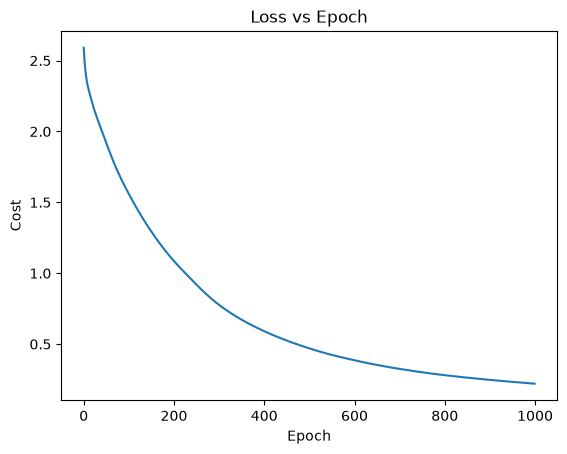

In [10]:
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Loss vs Epoch")
plt.show()

In [11]:
_, y_hat = forward(X_test)
predictions = np.argmax(y_hat, axis=0)
truth = np.argmax(y_test, axis=0)

print(metrics.classification_report(truth, predictions))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        38
           1       0.84      0.86      0.85        36
           2       0.85      0.94      0.89        35
           3       0.97      0.87      0.92        39
           4       0.85      0.97      0.91        30
           5       0.97      0.84      0.90        43
           6       0.95      0.95      0.95        39
           7       0.89      1.00      0.94        32
           8       1.00      0.76      0.86        37
           9       0.81      0.97      0.88        31

    accuracy                           0.91       360
   macro avg       0.91      0.91      0.91       360
weighted avg       0.92      0.91      0.91       360

